### EMEKA UCHE - Data Analyst Takehome Test (Zipline Systems Engineering)


### PART 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [3]:
df = pd.read_excel('Zipline_Data_Sample.xlsx', sheet_name=1)

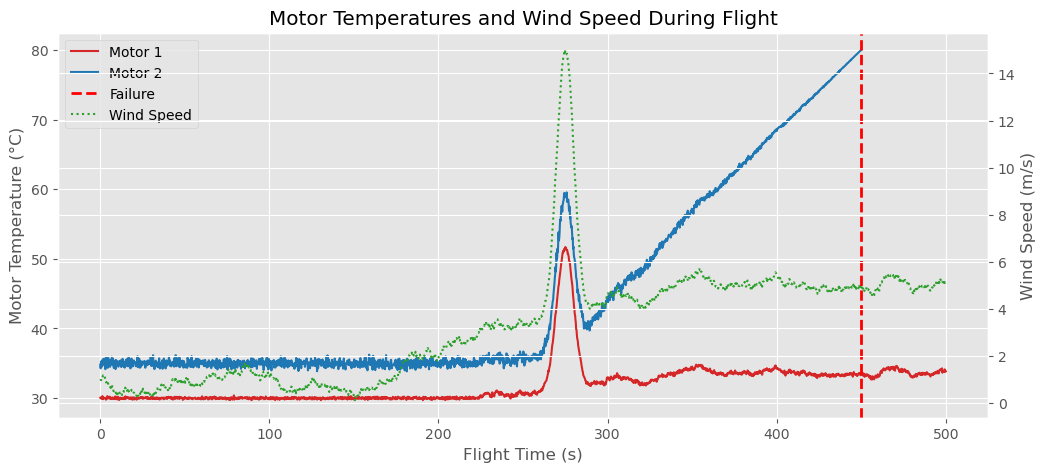

In [5]:
failure_time = df.loc[df['active_alarm'].notna(),
                      'flight_elapsed_time_s'].min()

fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(
    df['flight_elapsed_time_s'],
    df['motor_1_temperature_c'],
    label='Motor 1',
    color='tab:red'
)

ax1.plot(
    df['flight_elapsed_time_s'],
    df['motor_2_temperature_c'],
    label='Motor 2',
    color='tab:blue'
)


ax1.axvline(
    failure_time,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Failure'
)

ax1.set_xlabel('Flight Time (s)')
ax1.set_ylabel('Motor Temperature (°C)')



ax2 = ax1.twinx()

ax2.plot(
    df['flight_elapsed_time_s'],
    df['wind_speed_mps'],
    label='Wind Speed',
    color='tab:green',
    linestyle=':'
)

ax2.set_ylabel('Wind Speed (m/s)')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left'
)

plt.title('Motor Temperatures and Wind Speed During Flight')

#plt.savefig('Motor Temperatures and Wind Speed During Flight.png', dpi=300, bbox_inches='tight')

plt.show()

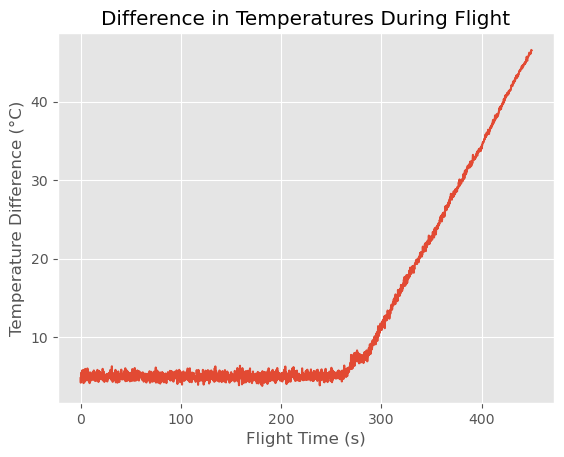

In [7]:
df['temp_difference'] = (
    df['motor_2_temperature_c']
    - df['motor_1_temperature_c']
)

plt.plot(df['flight_elapsed_time_s'],
         df['temp_difference'],
         label='Motor 1')

plt.xlabel('Flight Time (s)')
plt.ylabel('Temperature Difference (°C)')
plt.title('Difference in Temperatures During Flight')
#plt.legend()
#plt.savefig('Motor Temperatures During Flight.png', dpi=300, bbox_inches='tight')
plt.show()